# Tech Challenge 4 - Diagnóstico de Obesidade

**Objetivo:** Desenvolver um modelo preditivo para diagnosticar níveis de obesidade considerando um viés grave na base de dados, onde algumas classes estão restritas a um único gênero.

## Passos executados:
1. Carregamento e Análise Exploratória (EDA)
2. Engenharia de Features (Feature Engineering)
3. Tratamento do Viés de Dados (Omissão e Agrupamento)
4. Treinamento e Avaliação de Modelos
5. Exportação para Deploy

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

import joblib

## 1. Carregamento e Análise Exploratória (EDA)

Vamos carregar o dataset e visualizar a distribuição da variável alvo (`Obesity`) em relação à variável `Gender`. Isso nos ajudará a entender o tamanho do vazamento de dados (data leakage) atrelado ao gênero.

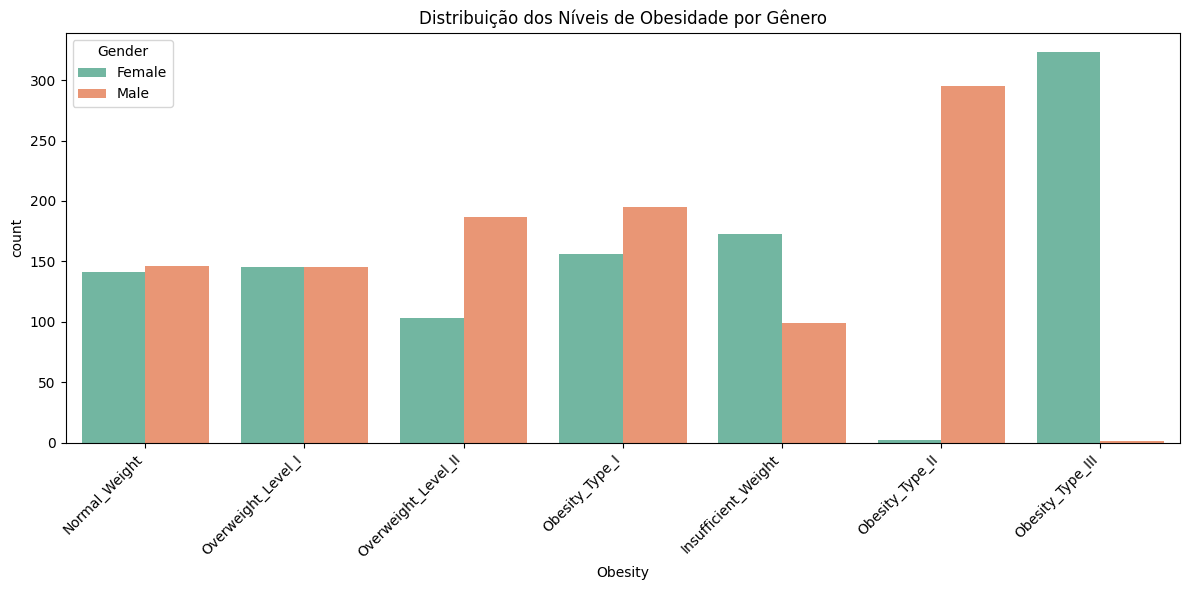

In [4]:
# Carregando os dados
df = pd.read_csv('dados/Obesity.csv')

# Visualização do Viés de Gênero
plt.figure(figsize=(12, 6))
sns.countplot(data=df, x='Obesity', hue='Gender', palette='Set2')
plt.xticks(rotation=45, ha='right')
plt.title('Distribuição dos Níveis de Obesidade por Gênero')
plt.tight_layout()
plt.show()

# O gráfico deve evidenciar que as classes Obesity_Type_II e Obesity_Type_III
# estão perfeitamente correlacionadas com um único gênero.

## 2. Engenharia de Features

Criaremos o Índice de Massa Corporal (IMC) baseado no Peso e Altura para adicionar mais poder preditivo e ajudar o modelo a generalizar. O encoding das variáveis será feito em Pipelines dinâmicas.

In [5]:
# Criando a feature IMC
df['IMC'] = df['Weight'] / (df['Height'] ** 2)

# Separando features (X) e target (y)
X = df.drop(columns=['Obesity'])
y = df['Obesity']

# Identificando colunas categóricas e numéricas iniciais
cat_cols = X.select_dtypes(include=['object']).columns.tolist()
num_cols = X.select_dtypes(include=['number']).columns.tolist()

## 3. Tratamento do Viés de Dados

Para mitigar o viés do gênero, vamos testar duas abordagens:

**Abordagem A (Omissão):** Remove a coluna `Gender`. O modelo precisará prever o nível de obesidade usando apenas o IMC e os hábitos.
**Abordagem B (Agrupamento):** Mantém a coluna `Gender`, mas simplifica o target, agrupando os tipos de obesidade em categorias mais amplas para remover a exclusividade de gênero nas classes.

In [6]:
# -----------------------------------------------------
# Abordagem A: Omissão de Gender
# -----------------------------------------------------
X_A = X.drop(columns=['Gender'])
cat_cols_A = [col for col in cat_cols if col != 'Gender']

preprocessor_A = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore', drop='first', sparse_output=False), cat_cols_A)
    ])

le_A = LabelEncoder()
y_A = le_A.fit_transform(y)

# -----------------------------------------------------
# Abordagem B: Agrupamento da Variável Alvo
# -----------------------------------------------------
def group_obesity_level(level):
    if 'Obesity' in level:
        return 'Obesity'
    elif 'Overweight' in level:
        return 'Overweight'
    else:
        return 'Normal_Underweight'

y_B_raw = y.apply(group_obesity_level)
le_B = LabelEncoder()
y_B = le_B.fit_transform(y_B_raw)

X_B = X.copy() # Mantemos Gender
preprocessor_B = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore', drop='first', sparse_output=False), cat_cols)
    ])

## 4. Treinamento e Avaliação do Modelo

Treinaremos Random Forest e XGBoost. Vamos avaliar a Acurácia (> 75%), o F1-Score através do Classification Report e plotar a Matriz de Confusão e a Importância de Features.

========== RESULTADOS: ABORDAGEM A (OMISSÃO) ==========

--- Random Forest ---
Acurácia: 0.9716
                     precision    recall  f1-score   support

Insufficient_Weight       1.00      0.96      0.98        82
      Normal_Weight       0.88      0.97      0.92        86
     Obesity_Type_I       0.97      1.00      0.99       106
    Obesity_Type_II       1.00      0.99      0.99        89
   Obesity_Type_III       1.00      1.00      1.00        97
 Overweight_Level_I       0.95      0.91      0.93        87
Overweight_Level_II       1.00      0.97      0.98        87

           accuracy                           0.97       634
          macro avg       0.97      0.97      0.97       634
       weighted avg       0.97      0.97      0.97       634



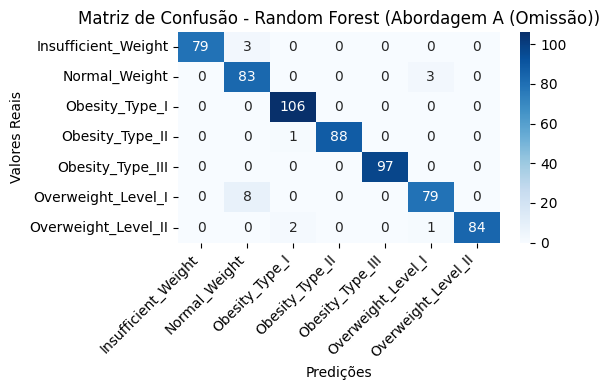

/Users/raulomirandahotmail.com/Desktop/TechChallenge4/TechChallenge4/Deploy de aplicações/.venv/lib/python3.10/site-packages/xgboost/training.py:200: UserWarning: [00:06:04] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



--- XGBoost ---
Acurácia: 0.9826
                     precision    recall  f1-score   support

Insufficient_Weight       0.99      0.99      0.99        82
      Normal_Weight       0.97      0.98      0.97        86
     Obesity_Type_I       0.99      1.00      1.00       106
    Obesity_Type_II       0.97      1.00      0.98        89
   Obesity_Type_III       1.00      0.97      0.98        97
 Overweight_Level_I       0.98      0.97      0.97        87
Overweight_Level_II       0.99      0.98      0.98        87

           accuracy                           0.98       634
          macro avg       0.98      0.98      0.98       634
       weighted avg       0.98      0.98      0.98       634



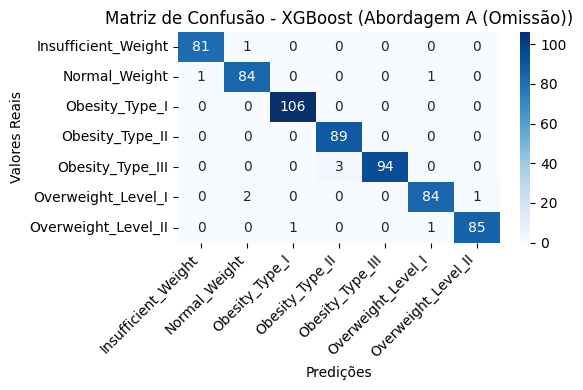


[Melhor Modelo para Abordagem A (Omissão): XGBoost com Acurácia de 0.9826]


/var/folders/2g/x76dsmn962x725mxhytr1ymh0000gn/T/ipykernel_23397/751408693.py:60: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=feat_df, x='Importance', y='Feature', palette='viridis')


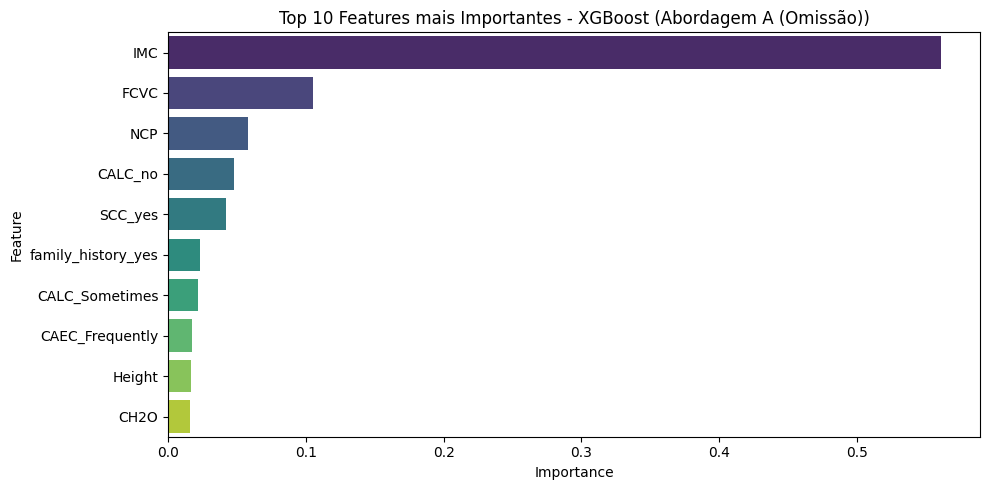

========== RESULTADOS: ABORDAGEM B (AGRUPAMENTO) ==========

--- Random Forest ---
Acurácia: 0.9905
                    precision    recall  f1-score   support

Normal_Underweight       0.99      0.98      0.99       168
           Obesity       1.00      1.00      1.00       292
        Overweight       0.98      0.98      0.98       174

          accuracy                           0.99       634
         macro avg       0.99      0.99      0.99       634
      weighted avg       0.99      0.99      0.99       634



/Users/raulomirandahotmail.com/Desktop/TechChallenge4/TechChallenge4/Deploy de aplicações/.venv/lib/python3.10/site-packages/sklearn/preprocessing/_encoders.py:228: UserWarning: Found unknown categories in columns [6] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


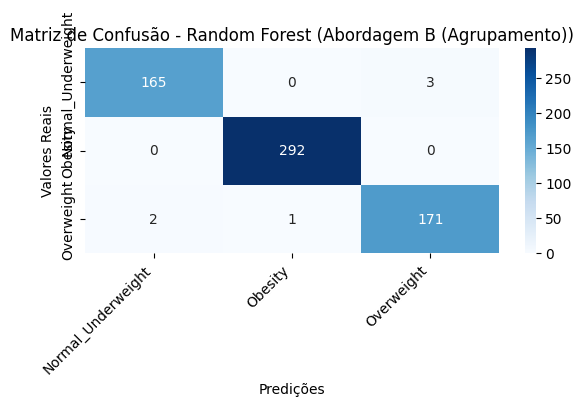

/Users/raulomirandahotmail.com/Desktop/TechChallenge4/TechChallenge4/Deploy de aplicações/.venv/lib/python3.10/site-packages/xgboost/training.py:200: UserWarning: [00:06:05] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



--- XGBoost ---
Acurácia: 0.9953
                    precision    recall  f1-score   support

Normal_Underweight       0.99      0.99      0.99       168
           Obesity       1.00      1.00      1.00       292
        Overweight       0.99      0.99      0.99       174

          accuracy                           1.00       634
         macro avg       0.99      0.99      0.99       634
      weighted avg       1.00      1.00      1.00       634



/Users/raulomirandahotmail.com/Desktop/TechChallenge4/TechChallenge4/Deploy de aplicações/.venv/lib/python3.10/site-packages/sklearn/preprocessing/_encoders.py:228: UserWarning: Found unknown categories in columns [6] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


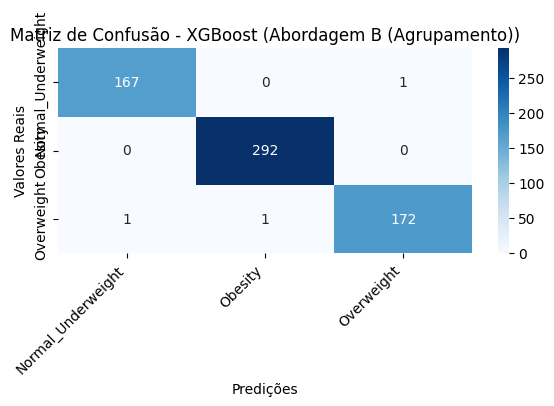

/var/folders/2g/x76dsmn962x725mxhytr1ymh0000gn/T/ipykernel_23397/751408693.py:60: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=feat_df, x='Importance', y='Feature', palette='viridis')



[Melhor Modelo para Abordagem B (Agrupamento): XGBoost com Acurácia de 0.9953]


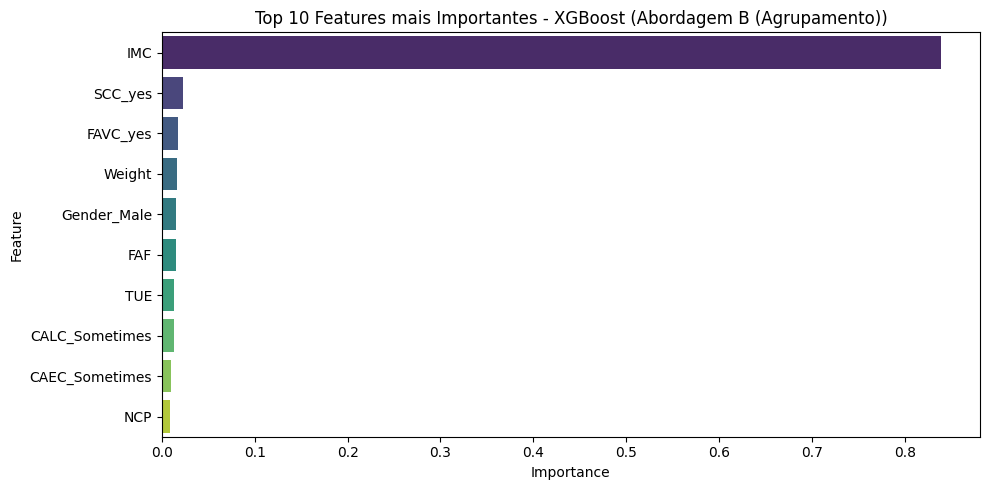

In [7]:
def train_evaluate_pipeline(X_data, y_data, preprocessor, le, approach_name, cat_columns):
    # Split 70/30
    X_train, X_test, y_train, y_test = train_test_split(X_data, y_data, test_size=0.3, random_state=42, stratify=y_data)
    
    models = {
        'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
        'XGBoost': XGBClassifier(random_state=42, eval_metric='mlogloss', use_label_encoder=False)
    }
    
    best_model_name = None
    best_pipeline = None
    best_acc = 0
    
    print(f"========== RESULTADOS: {approach_name.upper()} ==========")
    
    for name, model in models.items():
        pipe = Pipeline(steps=[('preprocessor', preprocessor), ('classifier', model)])
        pipe.fit(X_train, y_train)
        
        y_pred = pipe.predict(X_test)
        acc = accuracy_score(y_test, y_pred)
        print(f"\n--- {name} ---")
        print(f"Acurácia: {acc:.4f}")
        print(classification_report(y_test, y_pred, target_names=le.classes_))
        
        # Matriz de Confusão
        cm = confusion_matrix(y_test, y_pred)
        plt.figure(figsize=(6, 4))
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=le.classes_, yticklabels=le.classes_)
        plt.title(f'Matriz de Confusão - {name} ({approach_name})')
        plt.ylabel('Valores Reais')
        plt.xlabel('Predições')
        plt.xticks(rotation=45, ha='right')
        plt.tight_layout()
        plt.show()
        
        if acc > best_acc:
            best_acc = acc
            best_pipeline = pipe
            best_model_name = name

    print(f"\n[Melhor Modelo para {approach_name}: {best_model_name} com Acurácia de {best_acc:.4f}]")
    
    # Extrair e Plotar Feature Importances do melhor modelo
    classifier = best_pipeline.named_steps['classifier']
    if hasattr(classifier, 'feature_importances_'):
        # Obter os nomes das colunas numéricas (são mantidas)
        numeric_features = num_cols
        # Obter nomes das colunas criadas pelo OneHotEncoder
        ohe = best_pipeline.named_steps['preprocessor'].named_transformers_['cat']
        categorical_features = ohe.get_feature_names_out(cat_columns)
        
        feature_names = numeric_features + list(categorical_features)
        importances = classifier.feature_importances_
        
        feat_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
        feat_df = feat_df.sort_values(by='Importance', ascending=False).head(10)
        
        plt.figure(figsize=(10, 5))
        sns.barplot(data=feat_df, x='Importance', y='Feature', palette='viridis')
        plt.title(f'Top 10 Features mais Importantes - {best_model_name} ({approach_name})')
        plt.tight_layout()
        plt.show()
        
    return best_pipeline

# Executando a avaliação
best_pipe_A = train_evaluate_pipeline(X_A, y_A, preprocessor_A, le_A, 'Abordagem A (Omissão)', cat_cols_A)
best_pipe_B = train_evaluate_pipeline(X_B, y_B, preprocessor_B, le_B, 'Abordagem B (Agrupamento)', cat_cols)

## 5. Exportação para Deploy

Finalmente, exportamos o melhor modelo treinado (pipeline completa com encoders inclusos) e o mapeamento das labels (LabelEncoder) usando a biblioteca `joblib`. Isso nos permite subir a aplicação com Streamlit facilmente.

In [8]:
# Exportando os modelos e label encoders
# A pipeline inteira já contêm os scalers e onehotencoders!

joblib.dump(best_pipe_A, 'modelo_pipeline_abordagem_a.joblib')
joblib.dump(le_A, 'label_encoder_a.joblib')

joblib.dump(best_pipe_B, 'modelo_pipeline_abordagem_b.joblib')
joblib.dump(le_B, 'label_encoder_b.joblib')

print("✅ Modelos da Abordagem A e B exportados com sucesso para arquivos .joblib!")

✅ Modelos da Abordagem A e B exportados com sucesso para arquivos .joblib!
